In [2]:
from itertools import combinations

In [3]:
'''
Generates a list of all subgraphs of a graph G

Input: Sage graph object
Output: list of Sage graph objects
'''
def all_subgraphs(G):
    edges = G.edges(labels=True)
    V = G.vertices()
    subgraphs = []

    for k in range(len(edges) + 1):
        for E in combinations(edges, k):
            H = Graph()
            H.add_vertices(V)
            H.add_edges(E)
            subgraphs.append(H)

    return subgraphs

In [4]:
'''
Generates a list representing the degree sequence of G that is ordered

Input: Sage graph object
Output: List of int for the degree sequences
'''
def get_sequence(G):
    return [G.degree(v) for v in G.vertices()]

In [5]:
'''
Generates a nested list the edges of cycles of G
'''
def make_cycles(G):
    cycles = G.all_simple_cycles()
    cycs = []
    for c in cycles:
        c_edges = []
        for i in range(len(c) - 1):
            c_edges.append((c[i], c[i + 1]))
        cycs.append(c_edges)
    return cycs

In [6]:
'''
Generates a list of all subgraphs of G graph objects containing alternating cycles

We just have H as a 0-1 tuples and G is either the graph object or a list of tuples. 
And then we just want to see if that alternates in H. 

Output: 
'''
def find_alt_cycles(G):
    alt_cycles = []
    subs = all_subgraphs(G)
    cyc = make_cycles(G)
    for s in subs:
        e = {tuple(sorted(edge)) for edge in s.edges(labels=False)}
        for c in cyc:
            c = [tuple(sorted(edge)) for edge in c]
            c1 = c[::2]
            c2 = c[1::2]
            if (all(edge in e for edge in c1)) and (all(edge not in e for edge in c2)):
                alt_cycles.append(s)
                break
            elif (all(edge in e for edge in c2)) and (all(edge not in e for edge in c1)):
                alt_cycles.append(s)
                break

    return alt_cycles

In [7]:
def graph_to_indicator_tuple(G, vertices=None):
    """
    If `vertices` is provided, the tuple is indexed over that fixed vertex set
    rather than G's own vertices. This lets subgraph tuples stay position-
    compatible with the parent graph's tuple.

    Example:
        sage: G = Graph([(0,1), (1,2), (2,3)])
        sage: H = G.subgraph(vertices=[0,1,2])
        sage: all_verts = G.vertices()
        sage: graph_to_indicator_tuple(G, vertices=all_verts)
        (1, 0, 0, 1, 0, 1)
        sage: graph_to_indicator_tuple(H, vertices=all_verts)
        (1, 0, 0, 1, 0, 0)  # same length, same positions, (2,3) now 0
    """
    vertices = sorted(vertices if vertices is not None else G.vertices())
    edge_set = set(
        (min(u, v), max(u, v)) for u, v in G.edges(labels=False)
    )

    indicator = tuple(
        1 if (u, v) in edge_set else 0
        for i, u in enumerate(vertices)
        for v in vertices[i + 1:]
    )

    return indicator

def indicator_tuple_to_graph(indicator, vertices):
    """
    Convert a flat indicator tuple back into a SageMath undirected Graph.

    Parameters:
        indicator (tuple): A flat tuple of 0s and 1s, as produced by
                           graph_to_indicator_tuple.
        vertices (list):   The ordered list of vertices used when the
                           indicator tuple was created.

    Returns:
        sage.graphs.graph.Graph: The reconstructed undirected Graph.

    Example:
        sage: indicator_tuple_to_graph((1, 0, 0, 1, 0, 1), [0, 1, 2, 3])
        Graph on 4 vertices and 3 edges
    """
    vertices = sorted(vertices)
    pairs = [
        (u, v)
        for i, u in enumerate(vertices)
        for v in vertices[i + 1:]
    ]

    edges = [pair for pair, val in zip(pairs, indicator) if val == 1]

    G = Graph()
    G.add_vertices(vertices)
    G.add_edges(edges)

    return G

=== G ===
Graph on 4 vertices


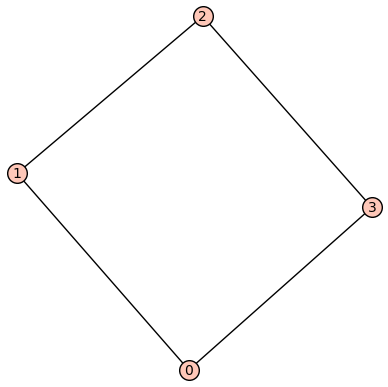


=== H (subgraph) ===
Subgraph of ()


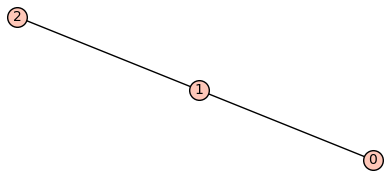


G edges: [(0, 1), (0, 3), (1, 2), (2, 3)]
H edges: [(0, 1), (1, 2)]

G tuple: (1, 0, 1, 1, 0, 1)
H tuple: (1, 0, 0, 1, 0, 0)



In [11]:
G = Graph([(0,1), (1,2), (2,3), (0,3)])
H = G.subgraph(vertices=[0,1,2])
all_verts = G.vertices()

g_tuple = graph_to_indicator_tuple(G, vertices=all_verts)
h_tuple = graph_to_indicator_tuple(H, vertices=all_verts)

print("=== G ===")
print(G)
G.show()

print("\n=== H (subgraph) ===")
print(H)
H.show()

print("\nG edges:", G.edges(labels=False))
print("H edges:", H.edges(labels=False))
print()
print("G tuple:", g_tuple)
print("H tuple:", h_tuple)
print()

Indicator: (1, 0, 0, 1, 0, 1)
Reconstructed: Graph on 4 vertices


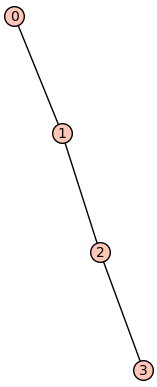

In [12]:
T = Graph([(0,1), (1,2), (2,3)])
all_verts = T.vertices()

indicator = graph_to_indicator_tuple(T, vertices=all_verts)
print("Indicator:", indicator)        # (1, 0, 0, 1, 0, 1)

T_reconstructed = indicator_tuple_to_graph(indicator, all_verts)
print("Reconstructed:", T_reconstructed)
T_reconstructed.show()

In [ ]:
'''
This function needs to complete the graph by finding the alt cycles first and
then filling up the remaining edges to the alt cycles

We get the 0-1 tuple and then find the missing edges and change those edges to 1
'''
def complete_alt_cycle(H, G, n):

# Main recursive function

In [ ]:
def getf():
    # Define f is a dictionary
    # This is the mapping for key: subforest G and value is subgraph
    # If we want the key H to be key, it needs to be an 0-1 tuple
    f = {} 
    if G_n.is_forest():
        for H subsetof G:
            f[H] = H # H is our 0-1 tuple
        return f
    
    # Get a list of all the subforests of G_n-1
    f_n_minus_1 = getf(G_n_minus_1)

    for H subsetof G:
        if H subsetof G_n_minus_1:
            f[H] = f_n_minus_1[H]
        else:
            # Completing all the subgraphs with alternating
            # cycles with 
            H_prime = f_n_minus_1(H \ edge) union edge
            f[H] = complete(H_prime)
    return f

In [ ]:
def main():
    G = new graph 
    call recursion
    verify 